In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from collections import defaultdict
import copy
import os
import pprint

import hydra
from omegaconf import OmegaConf
from einops import rearrange
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_theme(style='whitegrid', font_scale=1.3, palette=sns.color_palette('Set2'),)
import sqlalchemy as sa
import marimo as mo
import seaborn as sns
import lightning.pytorch
import polars as pl
from tqdm import tqdm

from conf import conf
from dafm import datasets, models, plots, utils

In [29]:
alt_ids = {
    # ('bz6r81zr', r'Score Matching (RMS)'): {},
    # ('75ypb7pg', r'Score Matching (LInfty)'): {},
    ('aet0vo3v', r'Score Matching (matching paper)'): {},
    # ('806lerm0', r'SMM (649520)'): {},
    # ('p3s7zz42', r'SMM (5113685)'): {},
    # ('1xb6wto5', r'SMM (5543464)'): {},
    # ('6ga8dhz9', r'SMM (1663576)'): {},
    # ('7kmx2xcx', r'SMM (1013721)'): {},
    # ('7hfcetdp', r'SMM (2347148)'): {},
    # ('xe4kqnc2', r'SMM (4141989)'): {},
    # ('wt5wrr1k', r'SMM (179266)'): {},
    # ('6o2xdada', r'SMM (4824560)'): {},

    # ('tbcsw46u', r'FMGT(MC)'): {},
    # ('dktv9tm6', r'FMM(MC)'): {},
    ('kesrdyzc', r'Flow Matching (model)'): {},
    # ('3shmbsh7', r'Flow Matching (shifted, scale X1 by time: true)'): {},
    # ('lrdc70d4', r'Flow Matching (shifted, scale X1 by time: false)'): {},
}
alt_id_to_label = dict(list(alt_ids))
label_to_alt_id = dict(map(reversed, alt_ids))
assert len(alt_ids) == len(label_to_alt_id), "Do two alt_id's have the same plot label?"

In [30]:
engine = conf.get_engine()
with conf.sa.orm.Session(engine) as db:
    cfgs = db.execute(sa.select(conf.Conf).where(conf.Conf.alt_id.in_([k[0] for k in alt_ids])))
    cfgs = {c.alt_id: c for (c,) in cfgs}
    cfgs = {k: {'cfg': cfgs[k[0]]} for k in alt_ids}
    pprint.pp(cfgs)

{('aet0vo3v', 'Score Matching (matching paper)'): {'cfg': Conf(root_dir='/home/sci/ttransue/GitHub/Data-Assimilation-Flow-Matching',
                                                               out_dir='/home/sci/ttransue/out/dafm',
                                                               run_subdir='runs',
                                                               prediction_filename='trajectories.parquet',
                                                               device='cuda',
                                                               alt_id='aet0vo3v',
                                                               rng_seed=2376999025,
                                                               fit=True,
                                                               id=45,
                                                               dataset=Lorenz96(save_only_mean_std=False,
                                                                                tra

In [31]:
engine = conf.get_engine()
with conf.sa.orm.Session(engine) as db:
    cfgs = db.execute(sa.select(conf.Conf).where(conf.Conf.alt_id.in_([k[0] for k in alt_ids])))
    cfgs = {c.alt_id: c for (c,) in cfgs}
    cfgs = {k: {'cfg': cfgs[k[0]]} for k in alt_ids}
    pprint.pp(cfgs)

{('aet0vo3v', 'Score Matching (matching paper)'): {'cfg': Conf(root_dir='/home/sci/ttransue/GitHub/Data-Assimilation-Flow-Matching',
                                                               out_dir='/home/sci/ttransue/out/dafm',
                                                               run_subdir='runs',
                                                               prediction_filename='trajectories.parquet',
                                                               device='cuda',
                                                               alt_id='aet0vo3v',
                                                               rng_seed=2376999025,
                                                               fit=True,
                                                               id=45,
                                                               dataset=Lorenz96(save_only_mean_std=False,
                                                                                tra

In [32]:
trajectories = []
for k, v in cfgs.items():
    trajectories.append(
        pl.scan_parquet(v['cfg'].run_dir/v['cfg'].prediction_filename)
        .select(
            pl.col('*'),
            alt_id=pl.lit(k[0]),
            Model=pl.lit(k[1]),
        )
    )
trajectories = pl.concat(trajectories)

In [33]:
predicted_state_trajectory = (
    trajectories.unpivot(
        on=pl.selectors.starts_with('predicted_state_'),
        index=[
            pl.col('alt_id'), pl.col('Model'),
            pl.col('times'),
        ],
        variable_name='ParticleAndDimension',
        value_name='State',
    )
    .select(
        pl.col('alt_id'), pl.col('Model'),
        pl.col('times'),
        pl.col('State'),
        Particle=pl.col('ParticleAndDimension').str.split('_').list[2].cast(int),
        Dimension=pl.col('ParticleAndDimension').str.split('_').list[4].cast(int),
        # Mean=pl.col('State').mean(1)
    )
)

In [34]:
true_state_trajectory = (
    trajectories.unpivot(
        on=pl.selectors.starts_with('true_state_'),
        index=[
            pl.col('alt_id'), pl.col('Model'),
            pl.col('times'),
        ],
        variable_name='Dimension',
        value_name='State',
    )
    .select(
        pl.col('alt_id'), pl.col('Model'),
        pl.col('times'),
        pl.col('State'),
        Particle=pl.lit('True'),
        Dimension=pl.col('Dimension').str.split('_').list[3].cast(int),
    )
)

In [35]:
observation_trajectory = (
    trajectories.unpivot(
        on=pl.selectors.starts_with('observation_'),
        index=[
            pl.col('alt_id'), pl.col('Model'),
            pl.col('times'),
        ],
        variable_name='Dimension',
        value_name='State',
    )
    .select(
        pl.col('alt_id'), pl.col('Model'),
        pl.col('times'),
        pl.col('State'),
        Particle=pl.lit('Observation'),
        Dimension=pl.col('Dimension').str.split('_').list[2].cast(int),
    )
)

In [43]:
rmse = (
    predicted_state_trajectory
    .group_by('alt_id', 'Model', 'times', 'Dimension')
    .agg(pl.col('State').mean().alias('Mean'))
    .join(
        true_state_trajectory,
        on=['alt_id', 'Model', 'times', 'Dimension'],
    )
    .select(
        pl.col('alt_id'), pl.col('Model'),
        pl.col('times'),
        pl.col('Dimension'),
        (pl.col('Mean') - pl.col('State')).pow(2).alias('DiffPow2'),
    )
    .group_by('alt_id', 'Model', 'times')
    .agg(pl.col('DiffPow2').mean().pow(1/2).alias('RMSE(dim)'))

    # # take last time steps
    # .sort('times')
    # .group_by('alt_id', 'Model')
    # .tail(50)

    .group_by('alt_id', 'Model')
    .agg(pl.col('RMSE(dim)').mean().alias('Mean(time) RMSE(dim)'))

    .collect()
)
print(rmse.mean())
rmse

shape: (1, 3)
┌────────┬───────┬──────────────────────┐
│ alt_id ┆ Model ┆ Mean(time) RMSE(dim) │
│ ---    ┆ ---   ┆ ---                  │
│ str    ┆ str   ┆ f64                  │
╞════════╪═══════╪══════════════════════╡
│ null   ┆ null  ┆ 0.282047             │
└────────┴───────┴──────────────────────┘


alt_id,Model,Mean(time) RMSE(dim)
str,str,f64
"""kesrdyzc""","""Flow Matching (model)""",0.291551
"""aet0vo3v""","""Score Matching (matching paper…",0.272542


In [37]:
dim_to_plot = 0
plot_identifier = 'Model'
if plot_identifier == 'alt_id':
    row_order = list(alt_id_to_label)
elif plot_identifier == 'Model':
    row_order = list(label_to_alt_id)
else:
    raise ValueError(f'Unknown plot identifier: {plot_identifier}')
hue_order = row_order

In [38]:
def map_true_state_trajectory(plot):
    for (row, col, hue), _ in plot.facet_data():
        ax = plot.axes[row][col]
        data = (
            true_state_trajectory
            .filter(**{
                'Dimension': dim_to_plot,
                plot_identifier: plot.row_names[row],
            })
            .collect()
            .to_pandas()
        )
        sns.lineplot(
            data=data,
            x='times',
            y='State',
            color='tab:gray',
            ax=ax,
            legend=False,
        )

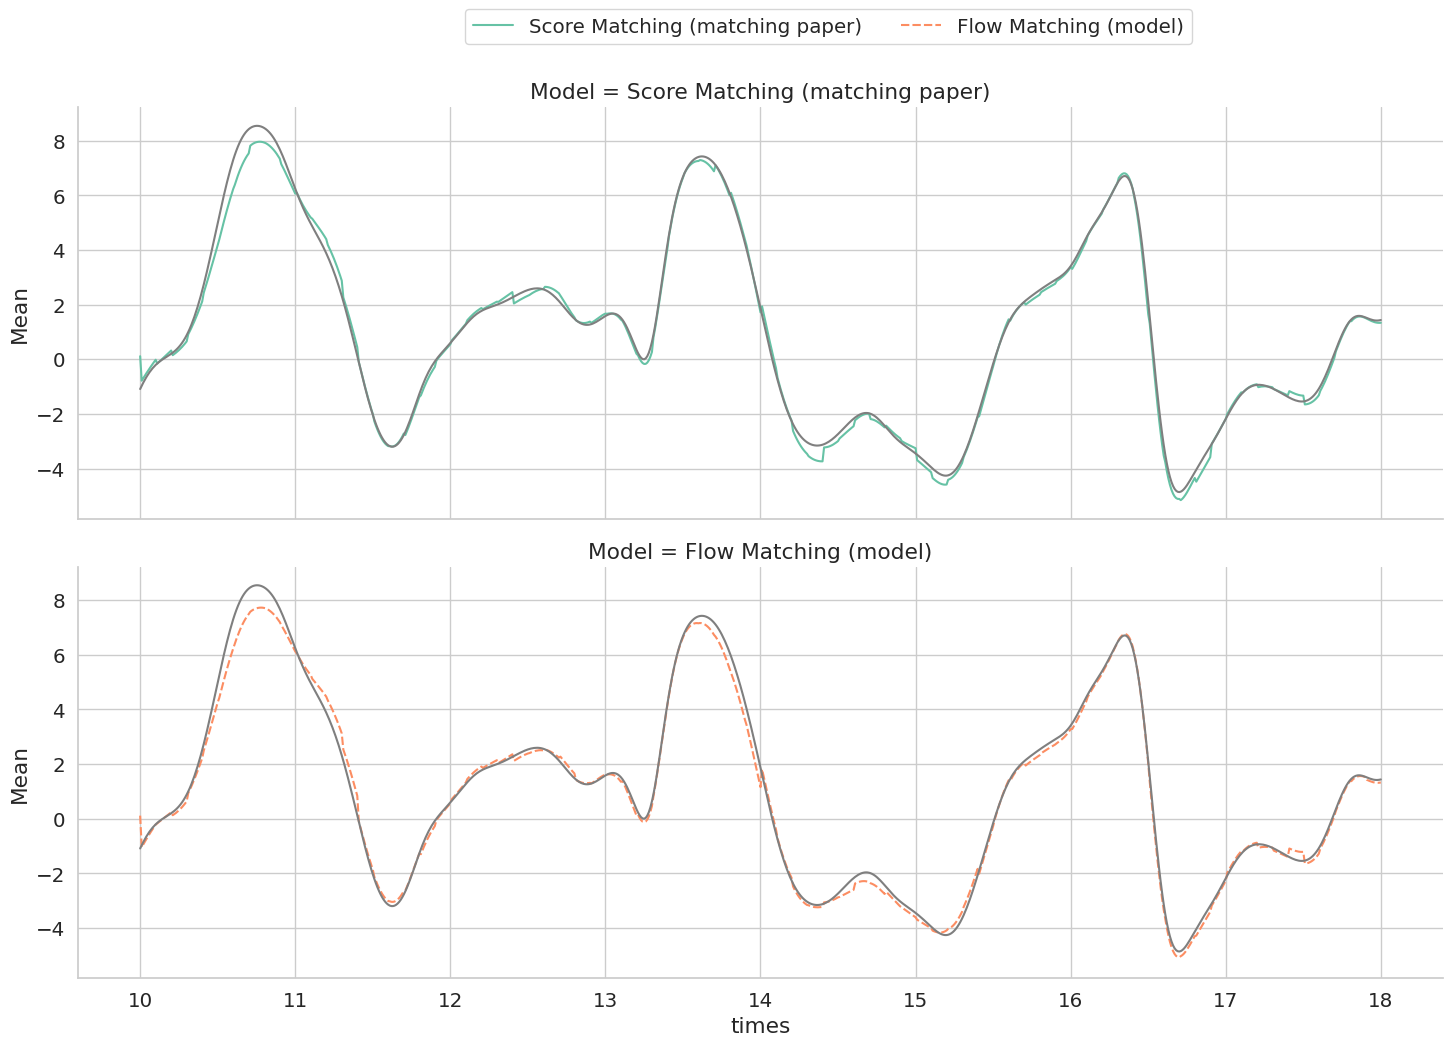

In [39]:
plot_predicted = (
    sns.relplot(
        kind='line',
        data=(
            predicted_state_trajectory
            .filter(Dimension=dim_to_plot)
            .group_by('alt_id', 'Model', 'times')
            .agg(pl.col('State').mean().alias('Mean'))
            .collect().to_pandas()
        ),
        x='times',
        y='Mean',
        row=plot_identifier,
        row_order=row_order,
        style=plot_identifier,
        hue=plot_identifier,
        hue_order=hue_order,
        aspect=3,
    )
    # .set(ylim=(-15, 15))
    # .set(xlim=(None, 32))
)
map_true_state_trajectory(plot_predicted)
sns.move_legend(
    plot_predicted,
    loc='upper center',
    ncol=min(len(alt_ids), 2) + 1,
    title='',
    bbox_to_anchor=(.455, 1.06),
    frameon=True,
    fancybox=True,
)
plot_predicted

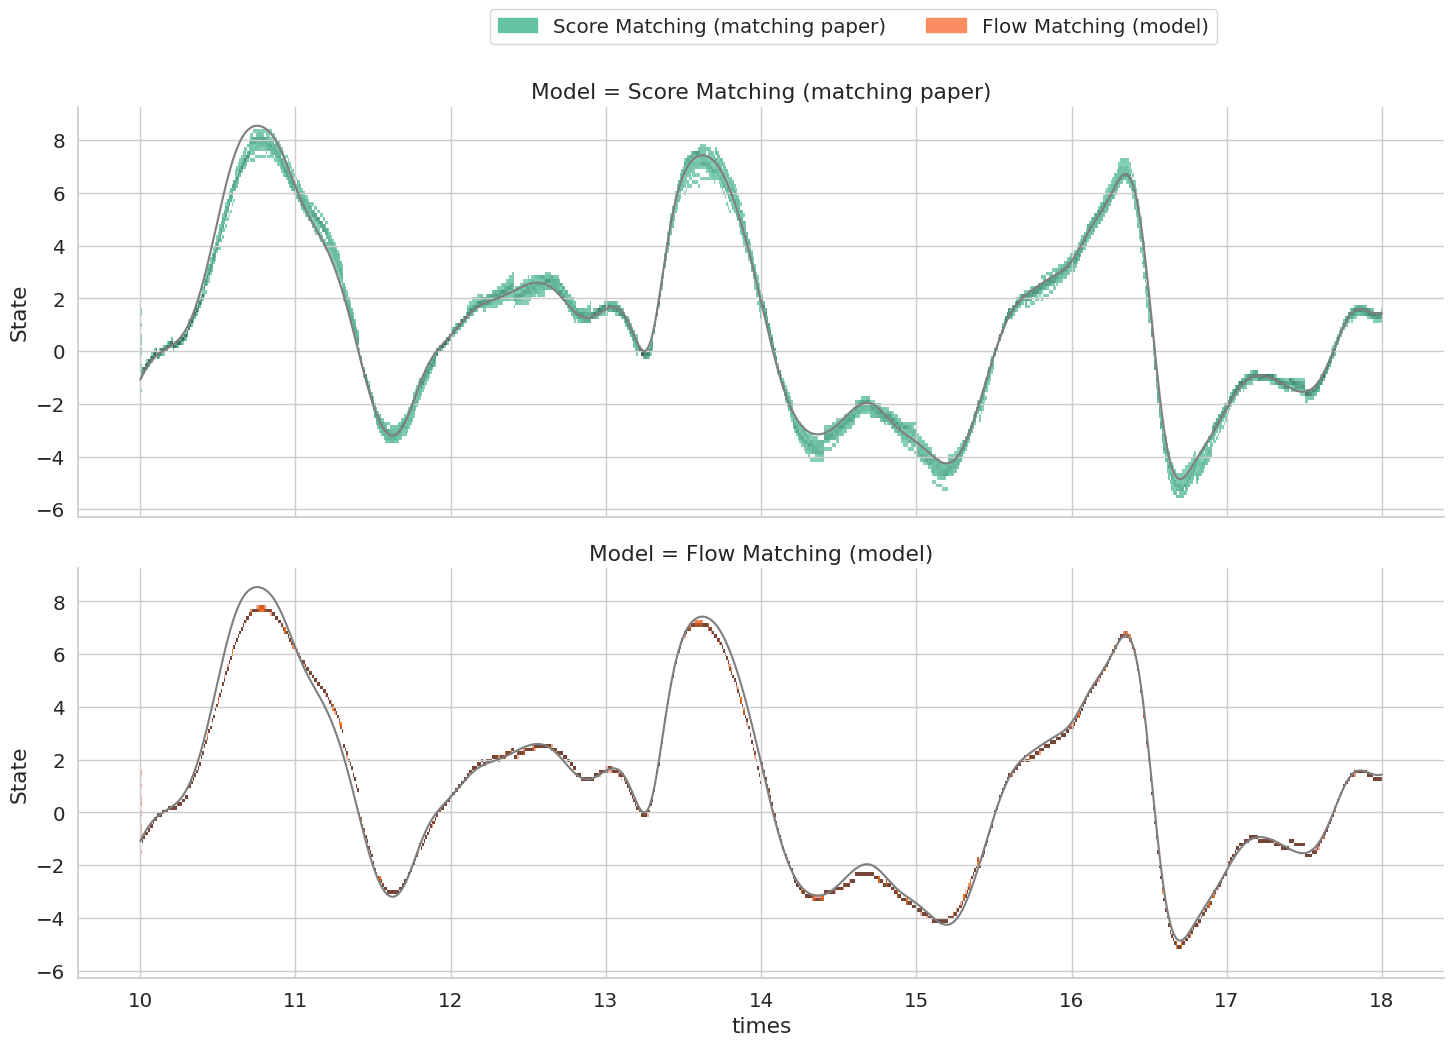

In [40]:
plot_histogram = (
    sns.displot(
        data=(
            predicted_state_trajectory
            .filter(Dimension=dim_to_plot)
            .collect().to_pandas()
        ),
        x='times',
        y='State',
        bins=(true_state_trajectory.select(pl.col('times')).collect().n_unique(), 101),
        row=plot_identifier,
        row_order=row_order,
        hue=plot_identifier,
        hue_order=hue_order,
        aspect=3,
        zorder=-1,
    )
    # .set(ylim=(-15, 15))
    # .set(xlim=(None, 40))
)
map_true_state_trajectory(plot_histogram)
sns.move_legend(
    plot_histogram,
    loc='upper center',
    ncol=min(len(alt_ids), 2) + 1,
    title='',
    bbox_to_anchor=(.455, 1.06),
    frameon=True,
    fancybox=True,
)
plot_histogram

In [41]:
# plots.save_all_subfigures(plot_predicted, 'Predicted', renaming=label_to_alt_id)
# plots.save_all_subfigures(plot_histogram, 'PredictedStateHistogram', renaming=label_to_alt_id)